# Troisième étape de modélisation: deuxième limite - Questions 1.2.5

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

rng = np.random.default_rng(42)

from helpers.helpers_QRNIID import *
from helpers.helpers_QR2LIM import *

rng = np.random.default_rng(42)

# Parameters from QRNIID.ipynb.
q0 = 10
mu_plus = 1.0
mu_minus = 1.1
alpha = 0.50
beta = 0.50
lambda_floor = 1e-8
gamma_cross = 1.0

eta = alpha / beta
lambda_minus_theory = theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta)

print(f"eta = alpha / beta = {eta:.3f}")
print("Strict eta < 1 condition satisfied:", eta < 1)
print(f"Theoretical stationary E[lambda_minus] = {lambda_minus_theory:.4f}")
print(f"gamma_cross = {gamma_cross:.2f}")


eta = alpha / beta = 1.000
Strict eta < 1 condition satisfied: False
Theoretical stationary E[lambda_minus] = 1.0500
gamma_cross = 1.00


## 1. Deuxieme limite constante

On ajoute les deuxiemes limites `N^{+2}` et `N^{-2}`. Dans cette premiere sous-question, leurs intensites d'ajout et de retrait sont constantes, comme dans le modele Poisson de la question 1.2.3. Les premieres limites `N^{+1}` et `N^{-1}` gardent la dynamique Hawkes couplee de la question 1.2.4.

Le point important est que, dans cette sous-question, les deuxiemes limites n'influencent pas les premieres. On peut donc separer exactement le probleme en deux blocs independants :

1. simuler les premieres limites Hawkes jusqu'au premier temps d'epuisement

```text
tau = min(tau_{+1}, tau_{-1}),
tau_{+1} = inf { t >= 0 : N^{+1}_t = 0 },
tau_{-1} = inf { t >= 0 : N^{-1}_t = 0 };
```

2. simuler independamment `N^{+2}` sur l'intervalle aleatoire `[0, tau]` avec des taux constants.

Dans le code precedent, `bid` correspond a `+1` et `ask` a `-1`. On estime alors deux lois empiriques :

```text
N^{+2}_tau | { tau = tau_{+1} }
N^{+2}_tau | { tau = tau_{-1} }
```

La deuxieme limite est une taille de file : son taux de retrait est constant lorsqu'elle est strictement positive, et vaut zero lorsqu'elle est deja vide. Autrement dit, le taux de retrait constant est une intensite de base, pas une permission de passer en taille negative.

Comme `N^{+2}` est ici independant des premieres limites, et comme le modele est symetrique entre `+1` et `-1`, les deux distributions conditionnelles doivent etre tres proches. Cette premiere sous-question sert donc de reference neutre avant d'ajouter le feedback de la question 1.2.5.2.

In [7]:
# Paramètres de la seconde limite à taux constant.
# Nous les maintenons proches des taux moyens de Hawkes à une limite afin que l'échelle soit comparable à celle de la section précédente.
q2_0 = q0
lambda_second_add = mu_plus
lambda_second_remove = lambda_minus_theory

print(f"Initial second-limit size q2_0 = {q2_0}")
print(f"Second-limit addition rate = {lambda_second_add:.3f}")
print(f"Second-limit removal rate  = {lambda_second_remove:.3f}")

Initial second-limit size q2_0 = 10
Second-limit addition rate = 1.000
Second-limit removal rate  = 1.050


In [ ]:
n_second_limit_samples = 5_000
second_limit_constant_samples = sample_second_limit_conditionals_constant(
    n_samples=n_second_limit_samples,
    q1_0=q0,
    q2_0=q2_0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    lambda_second_add=lambda_second_add,
    lambda_second_remove=lambda_second_remove,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=10_000.0,
)

first_empty = second_limit_constant_samples["first_empty"]
hit_zero = second_limit_constant_samples["hit_zero"]
plus2_at_tau = second_limit_constant_samples["plus2_at_tau"]

plus1_empty_mask = hit_zero & (first_empty == "plus1")
minus1_empty_mask = hit_zero & (first_empty == "minus1")

plus2_given_plus1_empty = plus2_at_tau[plus1_empty_mask]
plus2_given_minus1_empty = plus2_at_tau[minus1_empty_mask]

print(f"Number of simulations = {n_second_limit_samples}")
print(f"Hit probability before t_max = {hit_zero.mean():.4f}")
print(f"P(tau = tau_{{+1}}) = {plus1_empty_mask.mean():.4f}")
print(f"P(tau = tau_{{-1}}) = {minus1_empty_mask.mean():.4f}")
print()
print("Conditional distribution summaries for N^{+2}_tau")
print("Condition                         Count    Mean     Std     Q05     Q50     Q95")
print("----------------------------------------------------------------------------")

for label, values in [
    ("N^{+1}_tau = 0", plus2_given_plus1_empty),
    ("N^{-1}_tau = 0", plus2_given_minus1_empty),
]:
    q05, q50, q95 = np.quantile(values, [0.05, 0.50, 0.95])
    print(f"{label:<31} {len(values):5d}  {values.mean():7.3f} {values.std(ddof=1):7.3f} {q05:7.1f} {q50:7.1f} {q95:7.1f}")

ks_distance = empirical_cdf_distance(plus2_given_plus1_empty, plus2_given_minus1_empty)
mean_gap = plus2_given_plus1_empty.mean() - plus2_given_minus1_empty.mean()

print()
print(f"Empirical CDF distance between the two conditionals = {ks_distance:.4f}")
print(f"Mean gap = {mean_gap:.4f}")

Number of simulations = 5000
Hit probability before t_max = 1.0000
P(tau = tau_{+1}) = 0.4988
P(tau = tau_{-1}) = 0.5012

Conditional distribution summaries for N^{+2}_tau
Condition                         Count    Mean     Std     Q05     Q50     Q95
----------------------------------------------------------------------------
N^{+1}_tau = 0                   2494   10.004   7.790     0.0     9.0    24.0
N^{-1}_tau = 0                   2506   10.314   7.853     0.0     9.0    25.0

Empirical CDF distance between the two conditionals = 0.0238
Mean gap = -0.3100


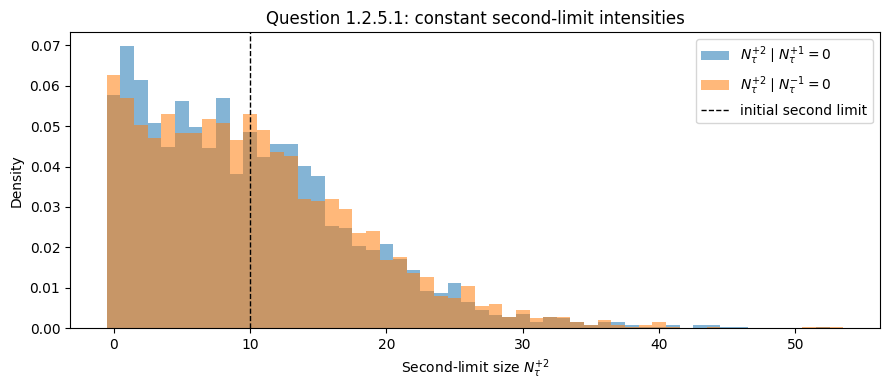

In [10]:
bins = np.arange(
    min(plus2_at_tau.min(), q2_0) - 0.5,
    max(plus2_at_tau.max(), q2_0) + 1.5,
    1.0,
)

plt.figure(figsize=(9, 4))
plt.hist(
    plus2_given_plus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{+1}_\tau = 0$",
)
plt.hist(
    plus2_given_minus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{-1}_\tau = 0$",
)
plt.axvline(q2_0, color="black", linestyle="--", linewidth=1, label="initial second limit")
plt.xlabel(r"Second-limit size $N^{+2}_\tau$")
plt.ylabel("Density")
plt.title("Question 1.2.5.1: constant second-limit intensities")
plt.legend()
plt.tight_layout()
plt.show()